# Approximate Hybrid Quantum State Preparation for a PPG Signal

## Imports

In [1]:
import sys
sys.path.append("../src")

In [2]:
import numpy as np
import pandas as pd
import os
import math
import matplotlib.pyplot as plt

from hybridqsp.transforms import haar_packet_transform, inverse_haar_packet_transform
from hybridqsp.quantum import build_inverse_qphwt_circuit
from hybridqsp.thresholding import top_k_threshold, magnitude_threshold
from hybridqsp.analysis import search_sparse_haar_representations
from hybridqsp.metrics import state_fidelity, trace_distance

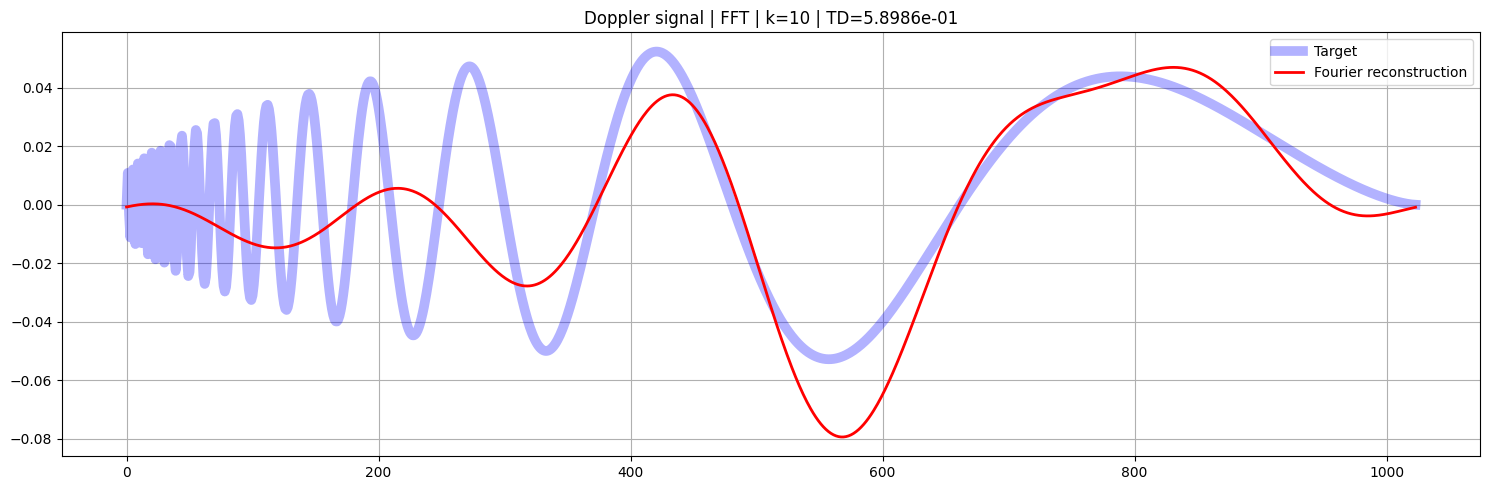

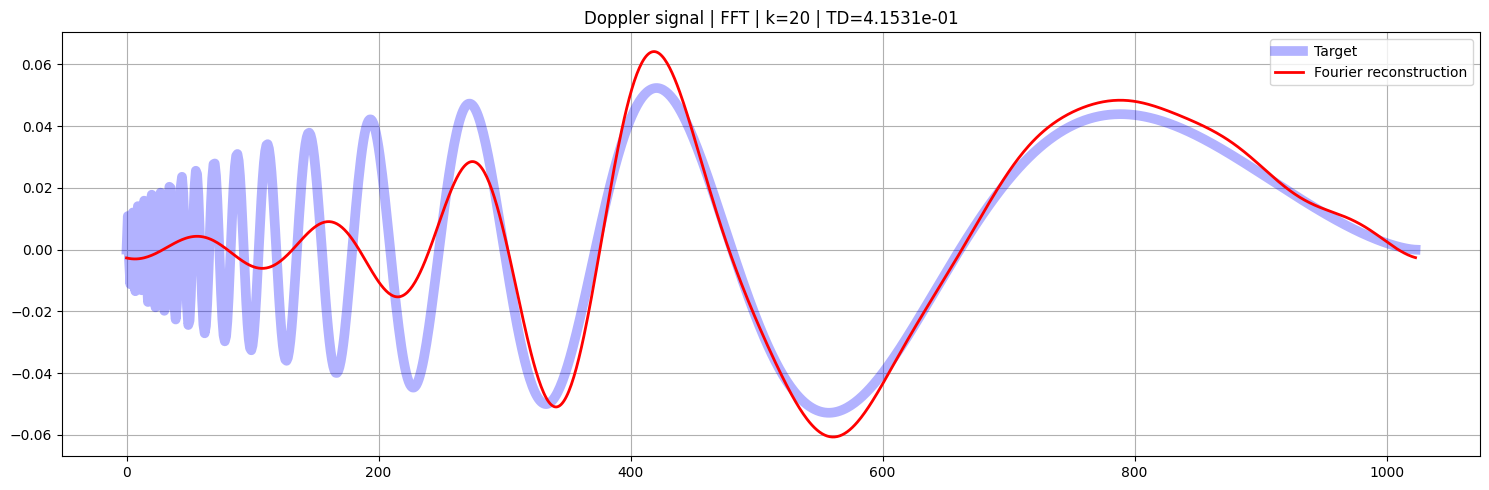

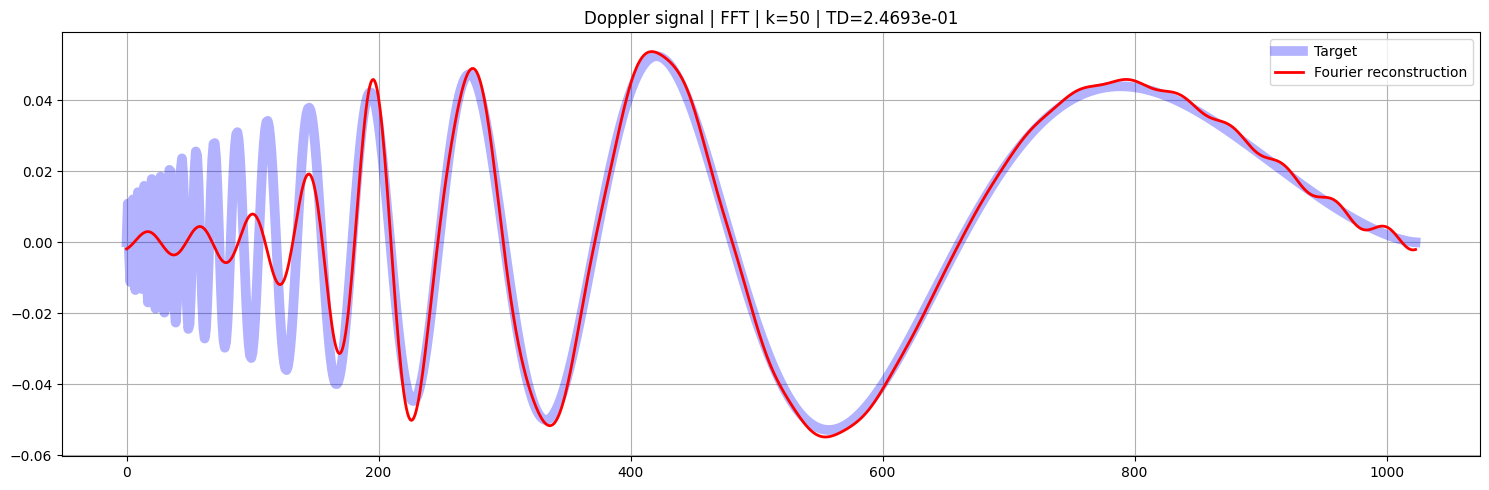

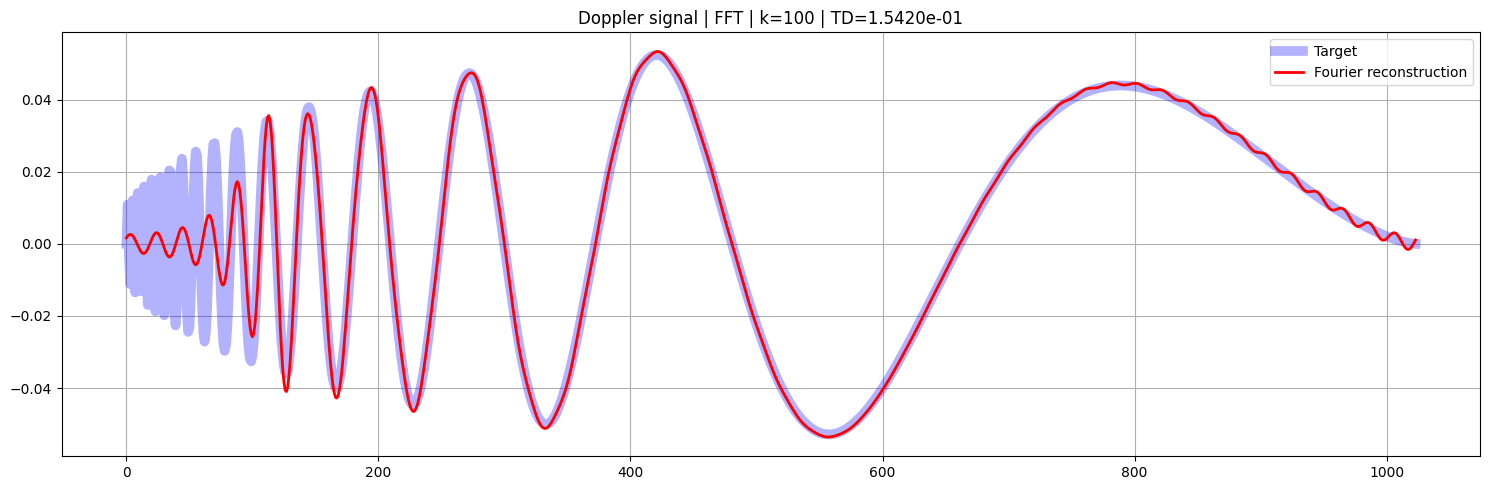

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Doppler benchmark signal (Donoho-Johnstone)
# ============================================================

n = 10
N = 2**n

t = np.linspace(0.01, 1.0, N)

signal = np.sqrt(t * (1 - t)) * np.sin((2 * np.pi * 1.05) / (t + 0.05))

signal /= np.linalg.norm(signal)

# ============================================================
# FFT
# ============================================================

X = np.fft.fft(signal)

# ============================================================
# Top-k threshold
# ============================================================

def topk(coeffs, k):

    out = np.zeros_like(coeffs)

    idx = np.argpartition(np.abs(coeffs), -k)[-k:]

    out[idx] = coeffs[idx]

    return out

# ============================================================
# Trace distance
# ============================================================

def trace_distance(x, y):

    x = x / np.linalg.norm(x)
    y = y / np.linalg.norm(y)

    overlap = np.vdot(x, y)

    return np.sqrt(max(0, 1 - np.abs(overlap)**2))

# ============================================================
# Fourier reconstruction
# ============================================================

for k in [10, 20, 50, 100]:

    Xk = topk(X, k)

    rec = np.fft.ifft(Xk).real
    rec /= np.linalg.norm(rec)

    TD = trace_distance(signal, rec)

    plt.figure(figsize=(15,5))

    plt.plot(
        signal,
        lw=7,
        alpha=0.3,
        color="blue",
        label="Target"
    )

    plt.plot(
        rec,
        lw=2,
        color="red",
        label="Fourier reconstruction"
    )

    plt.title(
        f"Doppler signal | FFT | k={k} | TD={TD:.4e}"
    )

    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

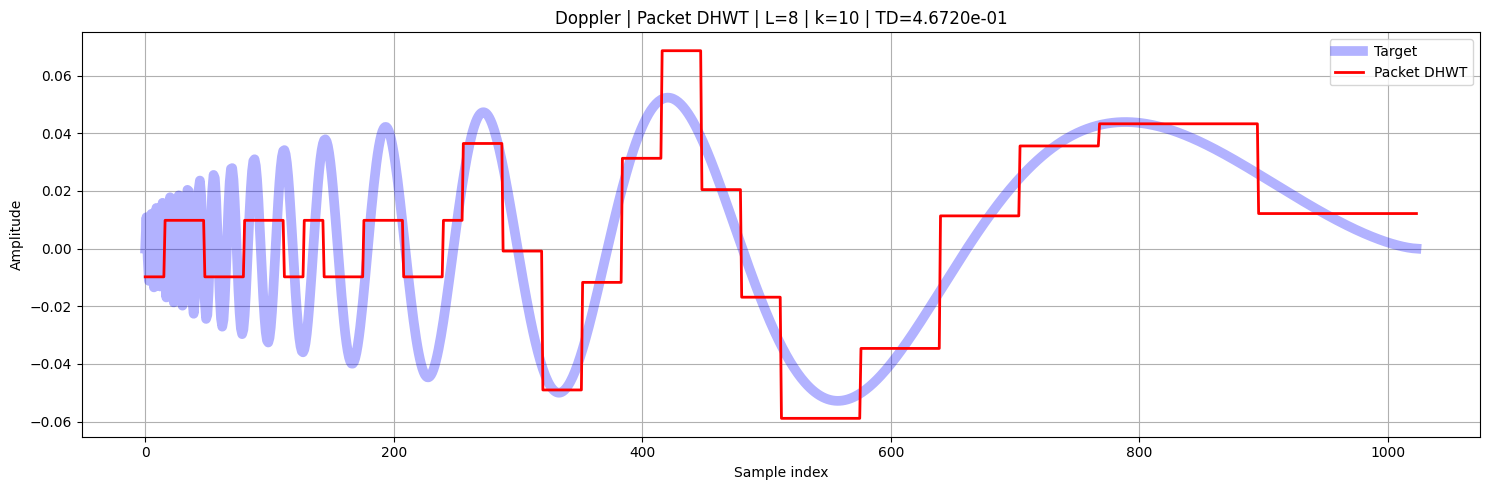

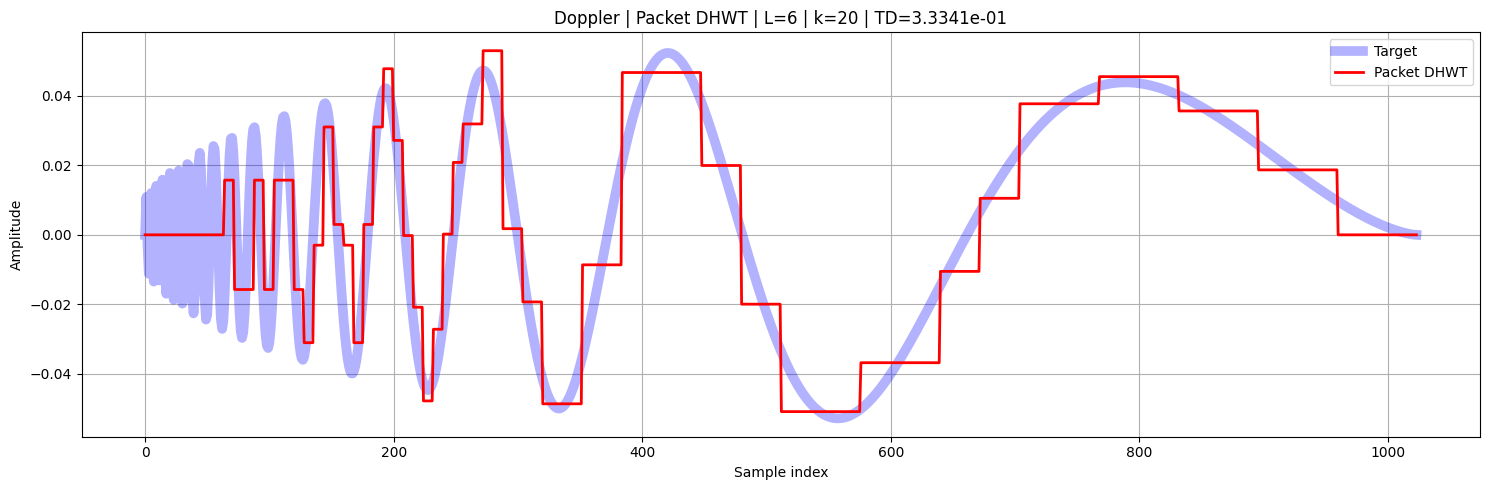

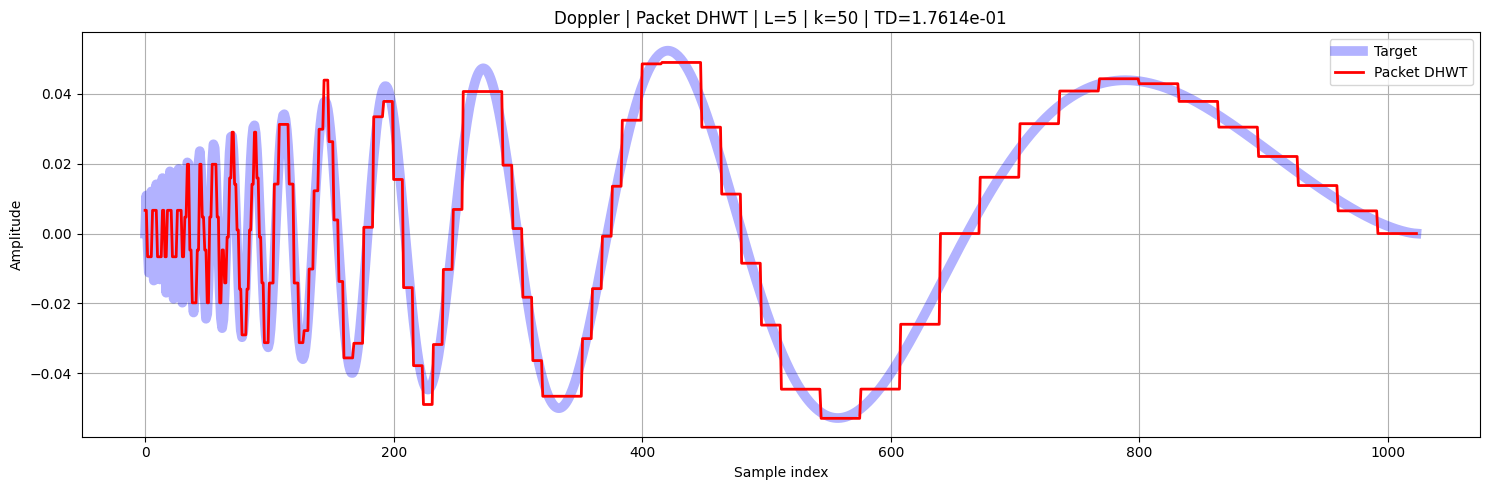

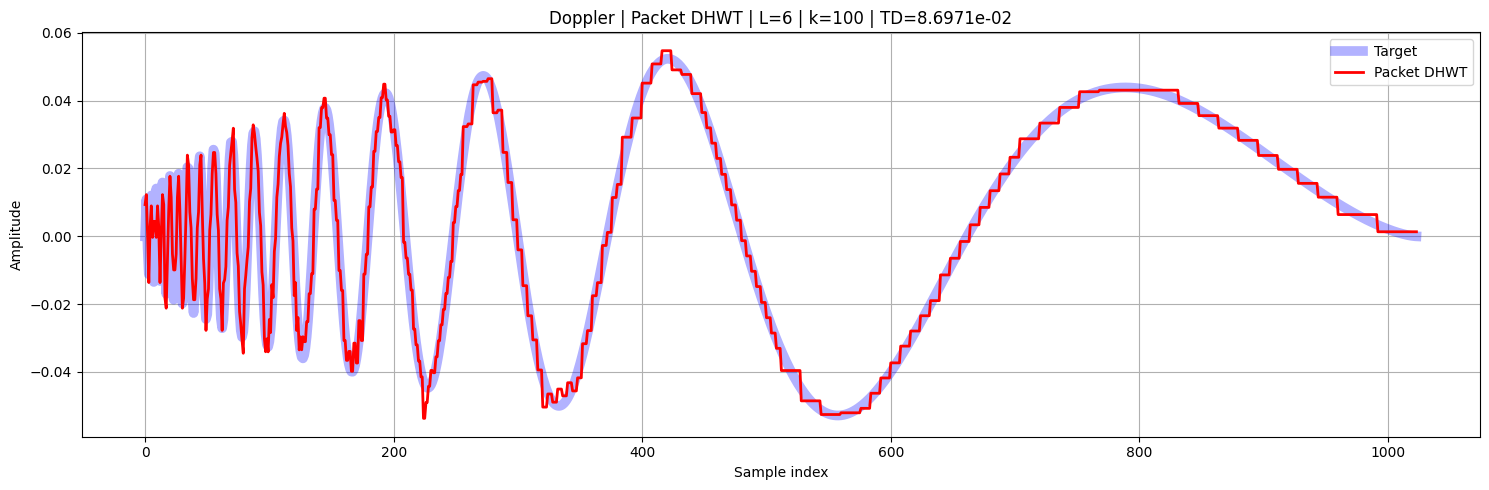

In [4]:
# ============================================================
# Packet DHWT reconstruction using optimal level
# ============================================================

for k in [10, 20, 50, 100]:

    # --------------------------------------------------------
    # Search for best decomposition level
    # --------------------------------------------------------

    best_td = np.inf
    best_level = None
    best_l2 = None

    for level in range(1, 10):

        coeffs = haar_packet_transform(
            signal,
            level=level
        )

        coeffs_k = top_k_threshold(
            coeffs,
            k
        )

        rec = inverse_haar_packet_transform(
            coeffs_k,
            level=level
        )

        rec /= np.linalg.norm(rec)

        td = trace_distance(signal, rec)
        l2 = np.linalg.norm(signal - rec)

        if td < best_td:

            best_td = td
            best_l2 = l2
            best_level = level

    # --------------------------------------------------------
    # Recompute reconstruction using the optimal level
    # --------------------------------------------------------

    coeffs = haar_packet_transform(
        signal,
        level=best_level
    )

    coeffs_k = top_k_threshold(
        coeffs,
        k
    )

    best_rec = inverse_haar_packet_transform(
        coeffs_k,
        level=best_level
    )

    best_rec /= np.linalg.norm(best_rec)

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.figure(figsize=(15,5))

    plt.plot(
        signal,
        color="blue",
        lw=7,
        alpha=0.30,
        label="Target"
    )

    plt.plot(
        best_rec,
        color="red",
        lw=2,
        label="Packet DHWT"
    )

    plt.title(
        f"Doppler | Packet DHWT | "
        f"L={best_level} | "
        f"k={k} | "
        f"TD={best_td:.4e}"
    )

    plt.xlabel("Sample index")
    plt.ylabel("Amplitude")

    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [5]:
# ============================================================
# Best packet DHWT reconstruction
# ============================================================

print("=" * 80)
print("Packet DHWT")
print("=" * 80)

for k in [10, 20, 50, 100]:

    best_td = np.inf
    best_l2 = np.inf
    best_level = None

    for level in range(1, 10):

        # Forward transform
        coeffs = haar_packet_transform(
            signal,
            level=level
        )

        # Top-k threshold
        coeffs_k = top_k_threshold(
            coeffs,
            k
        )

        # Reconstruction
        rec = inverse_haar_packet_transform(
            coeffs_k,
            level=level
        )

        rec /= np.linalg.norm(rec)

        # Metrics
        td = trace_distance(signal, rec)
        l2 = np.linalg.norm(signal - rec)

        if td < best_td:

            best_td = td
            best_l2 = l2
            best_level = level

    print(
        f"k={k:3d} | "
        f"Best level={best_level} | "
        f"TD={best_td:.6f} | "
        f"L2={best_l2:.6f}"
    )

Packet DHWT
k= 10 | Best level=8 | TD=0.467200 | L2=0.481349
k= 20 | Best level=6 | TD=0.333413 | L2=0.338288
k= 50 | Best level=5 | TD=0.176144 | L2=0.176837
k=100 | Best level=6 | TD=0.086971 | L2=0.087053


In [6]:
# ============================================================
# Fourier reconstruction
# ============================================================

print("=" * 80)
print("Fourier")
print("=" * 80)

# Forward transform
X = np.fft.fft(signal)

for k in [10, 20, 50, 100]:

    # Top-k threshold
    Xk = topk(X, k)

    # Reconstruction
    rec = np.fft.ifft(Xk).real

    # Normalize reconstructed state
    rec /= np.linalg.norm(rec)

    # Metrics
    td = trace_distance(signal, rec)
    l2 = np.linalg.norm(signal - rec)

    print(
        f"k={k:3d} | "
        f"TD={td:.6f} | "
        f"L2={l2:.6f}"
    )

Fourier
k= 10 | TD=0.589864 | L2=0.620479
k= 20 | TD=0.415312 | L2=0.425020
k= 50 | TD=0.246927 | L2=0.248861
k=100 | TD=0.154202 | L2=0.154665


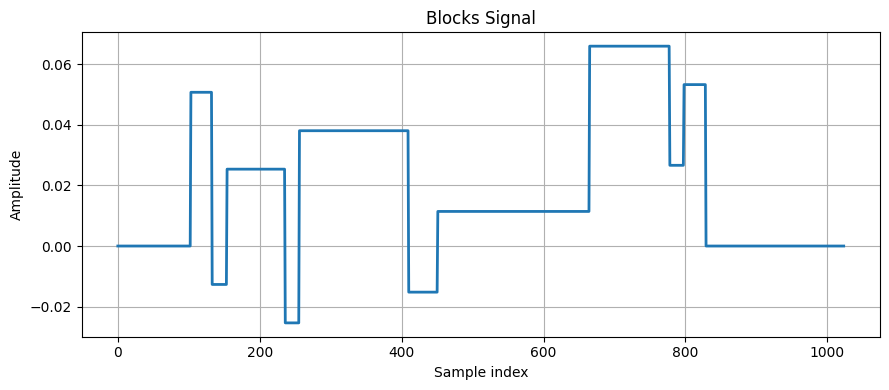

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Donoho-Johnstone Blocks signal
# ============================================================

n = 10
N = 2**n

t = np.linspace(0, 1, N)

# Locations and heights from Donoho & Johnstone
positions = np.array([
    0.10,
    0.13,
    0.15,
    0.23,
    0.25,
    0.40,
    0.44,
    0.65,
    0.76,
    0.78,
    0.81
])

heights = np.array([
     4,
    -5,
     3,
    -4,
     5,
    -4.2,
     2.1,
     4.3,
    -3.1,
     2.1,
    -4.2
])

signal = np.zeros_like(t)

for pos, h in zip(positions, heights):
    signal += h * (t >= pos)

# Normalize (for quantum-state comparison)
signal /= np.linalg.norm(signal)

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(9,4))

plt.plot(signal, lw=2)

plt.title("Blocks Signal")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")

plt.grid(True)

plt.tight_layout()
plt.show()

Fourier
k= 10 | TD=0.434360 | L2=0.445557


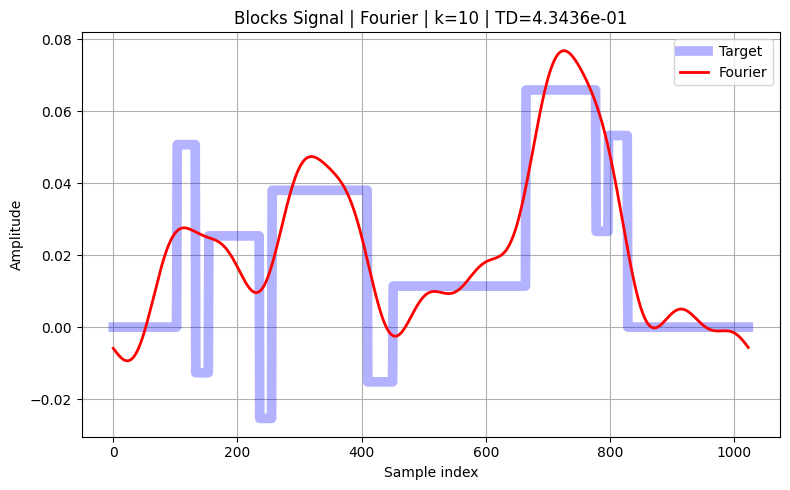

k= 20 | TD=0.344163 | L2=0.349543


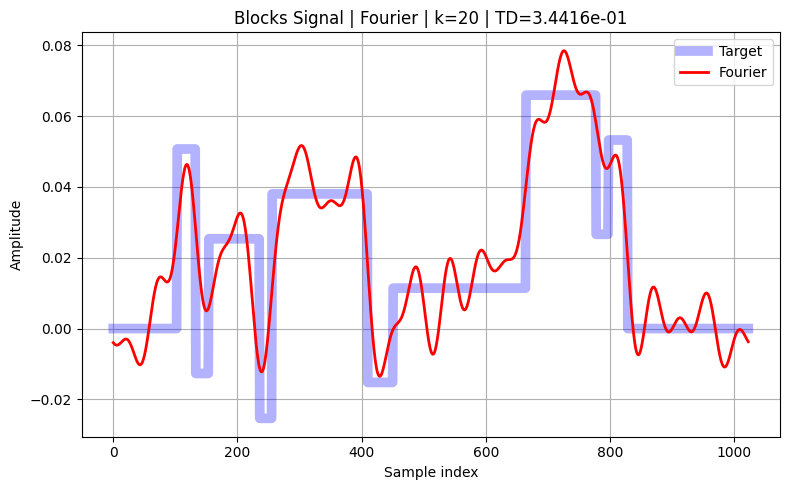

k= 50 | TD=0.209453 | L2=0.210624


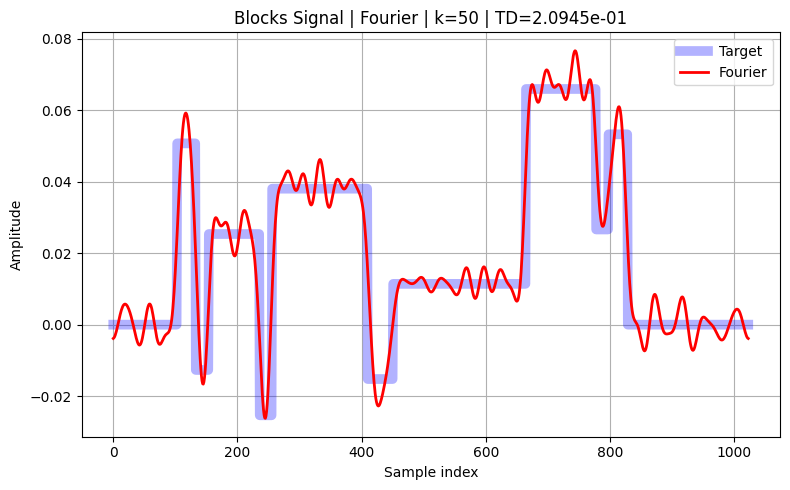

k=100 | TD=0.145145 | L2=0.145531


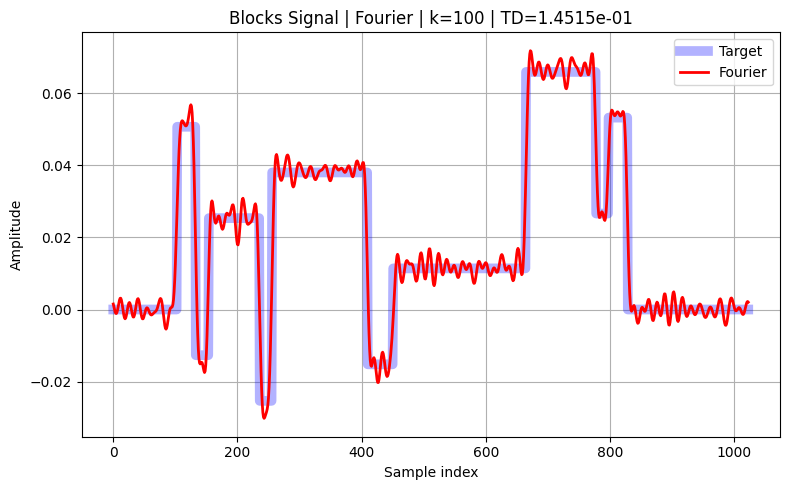

In [8]:
# ============================================================
# Fourier reconstruction (Blocks signal)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Top-k threshold
# ------------------------------------------------------------

def topk(coeffs, k):

    out = np.zeros_like(coeffs)

    idx = np.argpartition(np.abs(coeffs), -k)[-k:]

    out[idx] = coeffs[idx]

    return out

# ------------------------------------------------------------
# Trace distance
# ------------------------------------------------------------

def trace_distance(x, y):

    x = x / np.linalg.norm(x)
    y = y / np.linalg.norm(y)

    overlap = np.vdot(x, y)

    return np.sqrt(max(0.0, 1.0 - np.abs(overlap)**2))

# ============================================================
# Fourier transform
# ============================================================

X = np.fft.fft(signal)

print("=" * 80)
print("Fourier")
print("=" * 80)

for k in [10, 20, 50, 100]:

    # --------------------------------------------------------
    # Top-k threshold
    # --------------------------------------------------------

    Xk = topk(X, k)

    # --------------------------------------------------------
    # Reconstruction
    # --------------------------------------------------------

    rec = np.fft.ifft(Xk).real
    rec /= np.linalg.norm(rec)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    TD = trace_distance(signal, rec)
    L2 = np.linalg.norm(signal - rec)

    print(
        f"k={k:3d} | "
        f"TD={TD:.6f} | "
        f"L2={L2:.6f}"
    )

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.figure(figsize=(8,5))

    plt.plot(
        signal,
        color="blue",
        lw=7,
        alpha=0.30,
        label="Target"
    )

    plt.plot(
        rec,
        color="red",
        lw=2,
        label="Fourier"
    )

    plt.title(
        f"Blocks Signal | Fourier | "
        f"k={k} | TD={TD:.4e}"
    )

    plt.xlabel("Sample index")
    plt.ylabel("Amplitude")

    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

Packet DHWT
k= 10 | Best level=6 | TD=0.396485 | L2=0.404868


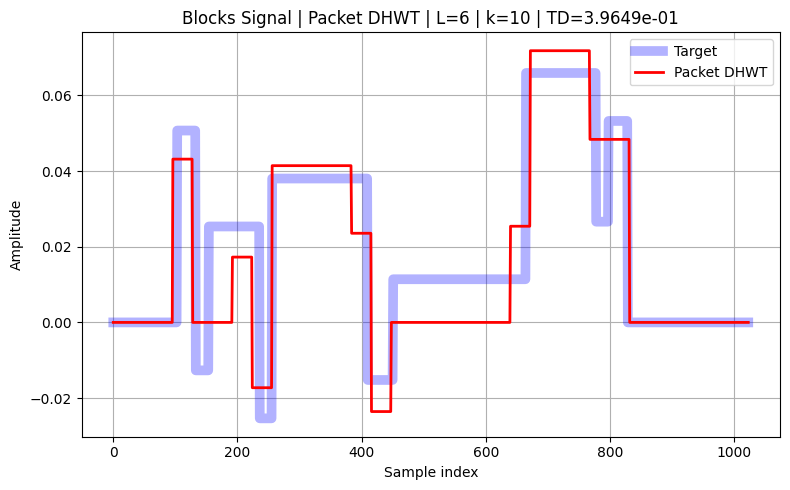

k= 20 | Best level=6 | TD=0.293356 | L2=0.296637


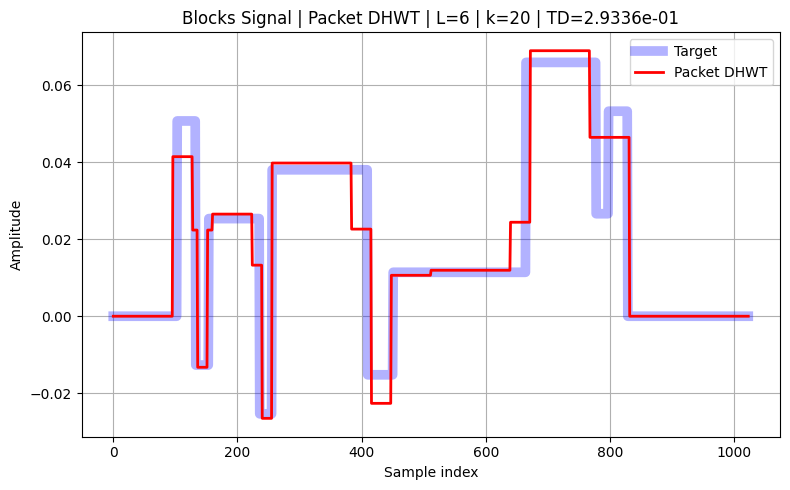

k= 50 | Best level=5 | TD=0.154022 | L2=0.154483


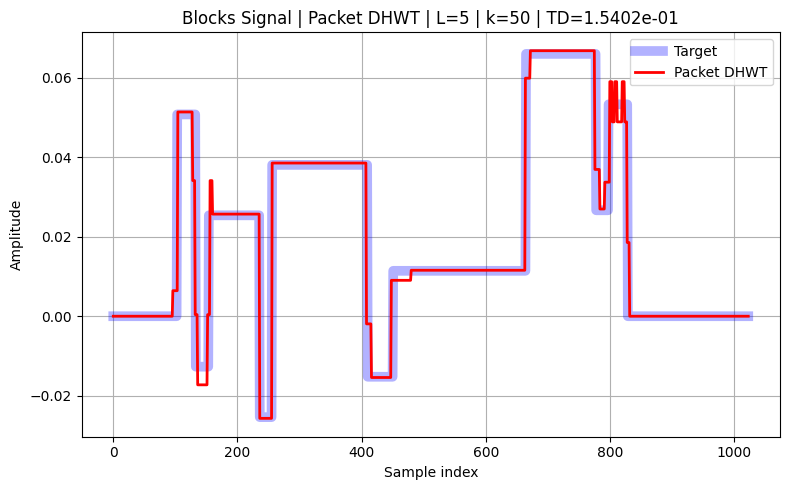

k=100 | Best level=4 | TD=0.085485 | L2=0.085563


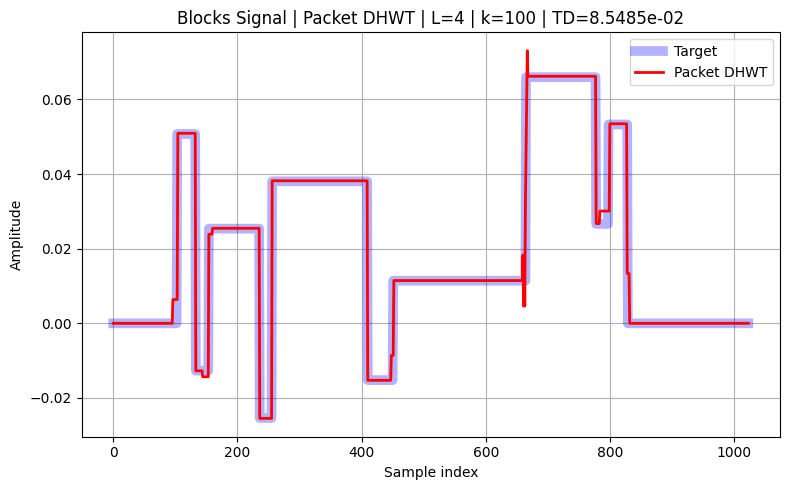

In [9]:
# ============================================================
# Packet DHWT reconstruction (Blocks signal)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

print("=" * 80)
print("Packet DHWT")
print("=" * 80)

for k in [10, 20, 50, 100]:

    # --------------------------------------------------------
    # Search for the best decomposition level
    # --------------------------------------------------------

    best_td = np.inf
    best_level = None
    best_rec = None

    for level in range(1, 10):

        # Forward transform
        coeffs = haar_packet_transform(
            signal,
            level=level
        )

        # Top-k threshold
        coeffs_k = top_k_threshold(
            coeffs,
            k
        )

        # Reconstruction
        rec = inverse_haar_packet_transform(
            coeffs_k,
            level=level
        )

        rec /= np.linalg.norm(rec)

        # Metrics
        td = trace_distance(signal, rec)

        if td < best_td:

            best_td = td
            best_level = level
            best_rec = rec.copy()

    # --------------------------------------------------------
    # Final metrics
    # --------------------------------------------------------

    L2 = np.linalg.norm(signal - best_rec)

    print(
        f"k={k:3d} | "
        f"Best level={best_level} | "
        f"TD={best_td:.6f} | "
        f"L2={L2:.6f}"
    )

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.figure(figsize=(8,5))

    plt.plot(
        signal,
        color="blue",
        lw=7,
        alpha=0.30,
        label="Target"
    )

    plt.plot(
        best_rec,
        color="red",
        lw=2,
        label="Packet DHWT"
    )

    plt.title(
        f"Blocks Signal | Packet DHWT | "
        f"L={best_level} | k={k} | "
        f"TD={best_td:.4e}"
    )

    plt.xlabel("Sample index")
    plt.ylabel("Amplitude")

    plt.grid(True)
    plt.legend()

    plt.tight_layout()

    plt.show()

In [10]:
level = 4
X = haar_packet_transform(signal,level)

k= 100
Xr = top_k_threshold(X,k)

x_norm = Xr/np.linalg.norm(Xr)
xrec = inverse_haar_packet_transform(x_norm, level)

print(trace_distance(xrec, signal))

0.08548500162928636


In [11]:
# ============================================================
# Packet DHWT: Best trace distance for each k
# ============================================================

print("=" * 80)
print("Packet DHWT")
print("=" * 80)

for k in [10, 20, 50, 100]:

    best_td = np.inf
    best_l2 = np.inf
    best_level = None

    for level in range(1, 10):

        # Forward transform
        coeffs = haar_packet_transform(
            signal,
            level=level
        )

        # Top-k threshold
        coeffs_k = top_k_threshold(
            coeffs,
            k
        )

        # Reconstruction
        rec = inverse_haar_packet_transform(
            coeffs_k,
            level=level
        )

        # Normalize
        rec /= np.linalg.norm(rec)

        # Metrics
        td = trace_distance(signal, rec)
        l2 = np.linalg.norm(signal - rec)

        if td < best_td:
            best_td = td
            best_l2 = l2
            best_level = level

    print(
        f"k={k:3d} | "
        f"Best level={best_level} | "
        f"TD={best_td:.6f} | "
        f"L2={best_l2:.6f}"
    )

Packet DHWT
k= 10 | Best level=6 | TD=0.396485 | L2=0.404868
k= 20 | Best level=6 | TD=0.293356 | L2=0.296637
k= 50 | Best level=5 | TD=0.154022 | L2=0.154483
k=100 | Best level=4 | TD=0.085485 | L2=0.085563


In [12]:
import pywt

# ============================================================
# Pyramid Haar (Mallat DWT)
# ============================================================

print("=" * 80)
print("Pyramid Haar (Mallat DWT)")
print("=" * 80)

wavelet = "haar"

for k in [10, 20, 50, 100]:

    best_td = np.inf
    best_l2 = np.inf
    best_level = None

    # Maximum admissible decomposition level
    max_level = pywt.dwt_max_level(
        len(signal),
        pywt.Wavelet(wavelet).dec_len
    )

    for level in range(1, max_level + 1):

        # ----------------------------------------------------
        # Forward DWT
        # ----------------------------------------------------

        coeffs = pywt.wavedec(
            signal,
            wavelet=wavelet,
            level=level,
            mode="periodization"
        )

        # Flatten coefficients
        coeff_array, coeff_slices = pywt.coeffs_to_array(coeffs)

        # ----------------------------------------------------
        # Top-k threshold
        # ----------------------------------------------------

        coeff_array_k = top_k_threshold(
            coeff_array,
            k
        )

        # Restore coefficient structure
        coeffs_k = pywt.array_to_coeffs(
            coeff_array_k,
            coeff_slices,
            output_format="wavedec"
        )

        # ----------------------------------------------------
        # Inverse DWT
        # ----------------------------------------------------

        rec = pywt.waverec(
            coeffs_k,
            wavelet=wavelet,
            mode="periodization"
        )

        rec = rec[:len(signal)]
        rec /= np.linalg.norm(rec)

        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        td = trace_distance(signal, rec)
        l2 = np.linalg.norm(signal - rec)

        if td < best_td:

            best_td = td
            best_l2 = l2
            best_level = level

    print(
        f"k={k:3d} | "
        f"Best level={best_level} | "
        f"TD={best_td:.6f} | "
        f"L2={best_l2:.6f}"
    )

Pyramid Haar (Mallat DWT)
k= 10 | Best level=6 | TD=0.396485 | L2=0.404868
k= 20 | Best level=7 | TD=0.253820 | L2=0.255924
k= 50 | Best level=7 | TD=0.056129 | L2=0.056151
k=100 | Best level=4 | TD=0.000000 | L2=0.000000


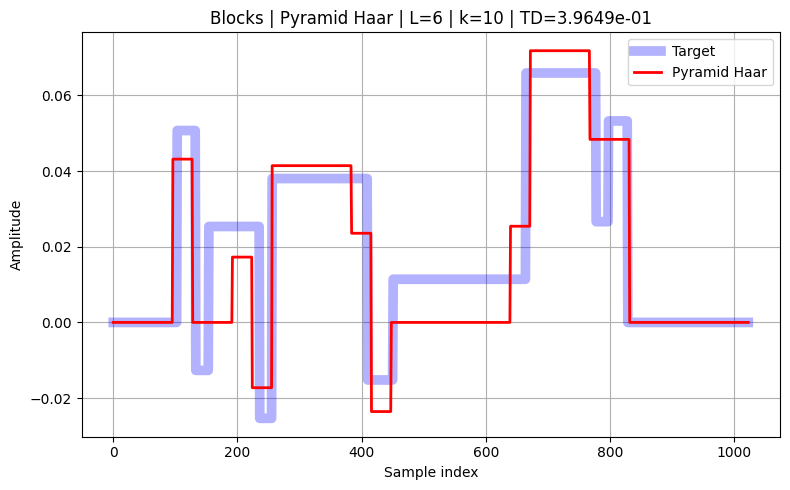

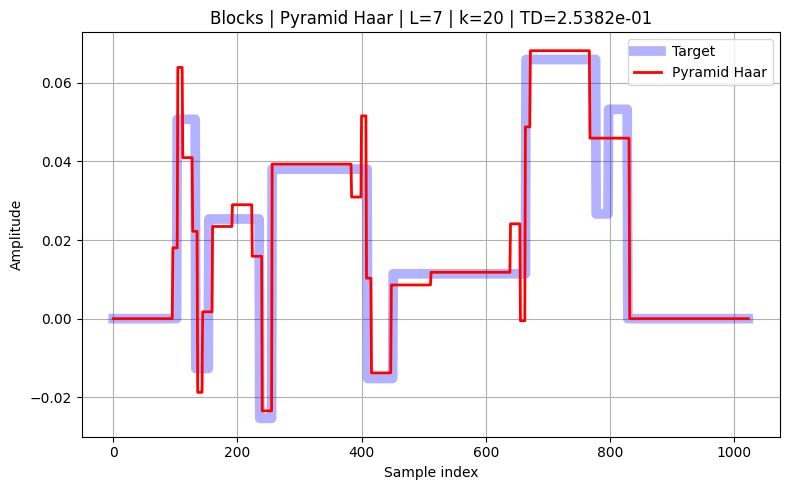

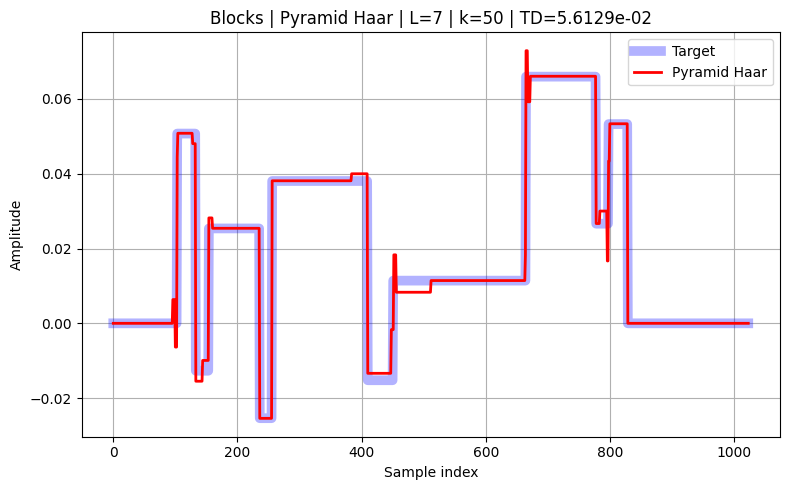

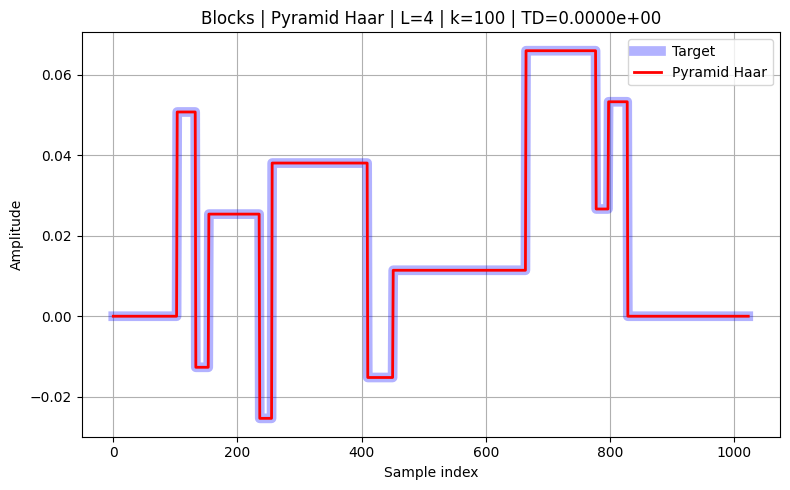

In [13]:
# ============================================================
# Plot best Pyramid Haar reconstructions
# ============================================================

import matplotlib.pyplot as plt
import pywt

wavelet = "haar"

for k in [10, 20, 50, 100]:

    best_td = np.inf
    best_level = None
    best_rec = None

    max_level = pywt.dwt_max_level(
        len(signal),
        pywt.Wavelet(wavelet).dec_len
    )

    for level in range(1, max_level + 1):

        # Forward transform
        coeffs = pywt.wavedec(
            signal,
            wavelet=wavelet,
            level=level,
            mode="periodization"
        )

        coeff_array, coeff_slices = pywt.coeffs_to_array(coeffs)

        # Top-k threshold
        coeff_array_k = top_k_threshold(
            coeff_array,
            k
        )

        # Restore coefficient structure
        coeffs_k = pywt.array_to_coeffs(
            coeff_array_k,
            coeff_slices,
            output_format="wavedec"
        )

        # Reconstruction
        rec = pywt.waverec(
            coeffs_k,
            wavelet=wavelet,
            mode="periodization"
        )

        rec = rec[:len(signal)]
        rec /= np.linalg.norm(rec)

        td = trace_distance(signal, rec)

        if td < best_td:
            best_td = td
            best_level = level
            best_rec = rec.copy()

    L2 = np.linalg.norm(signal - best_rec)

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.figure(figsize=(8,5))

    plt.plot(
        signal,
        color="blue",
        lw=7,
        alpha=0.30,
        label="Target"
    )

    plt.plot(
        best_rec,
        color="red",
        lw=2,
        label="Pyramid Haar"
    )

    plt.title(
        f"Blocks | Pyramid Haar | "
        f"L={best_level} | "
        f"k={k} | "
        f"TD={best_td:.4e}"
    )

    plt.xlabel("Sample index")
    plt.ylabel("Amplitude")

    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()